#  Tomato Disease Detection
### Using Convolutional Autoencoder (CAE) + CNN Classifier

**What this notebook does:**
1. Downloads the PlantVillage dataset from Kaggle
2. Trains a Convolutional Autoencoder (CAE)
3. Trains a CNN classifier on CAE output
4. Predicts disease and suggests treatment

**Before running:** Go to `Runtime` → `Change runtime type` → Select **GPU**

## Step 1: Connect Google Drive (to save your models)

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive connected!')

Mounted at /content/drive
✅ Google Drive connected!


## Step 2: Set up Kaggle API

1. Go to [https://www.kaggle.com/settings](https://www.kaggle.com/settings)
2. Scroll to **API** section
3. Under Legacy API Credentials click **Create Legacy API Key** — this downloads `kaggle.json`
4. Run the cell below and upload that file when prompted

In [2]:
from google.colab import files
import os

# Upload your kaggle.json
print('Upload your kaggle.json file:')
uploaded = files.upload()

# Place it where Kaggle expects it
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print('Kaggle API key set up successfully!')

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Kaggle API key set up successfully!


## Step 3: Download the PlantVillage Dataset

In [3]:
!pip install kaggle --quiet
!kaggle datasets download -d abdallahalidev/plantvillage-dataset --unzip -p ./plantvillage
print('Dataset downloaded and unzipped!')

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:11<00:00, 190MB/s]

Dataset downloaded and unzipped!


## Step 4: Imports & Config

In [46]:

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import glob
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Input, Dense, Conv2D, MaxPooling2D,
    Reshape, UpSampling2D, Flatten, Dropout
)
from tensorflow.keras.models import Model

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Image config
H, W, C = 128, 128, 3
batch_size=32
# Dataset path (adjust if folder structure differs)
TRAIN_DIR = '/content/plantvillage/plantvillage dataset/color'

CLASS_NAMES = [
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold',
    'Tomato___Septoria_leaf_spot',
    'Tomato___Spider_mites_Two_spotted_spider_mite',
    'Tomato___Target_Spot',
    'Tomato___Tomato_YellowLeaf__Curl_Virus',
    'Tomato___Tomato_mosaic_virus',
    'Tomato___healthy'
]

SOLUTIONS = {
    0: "Plow down crop residue after harvest. Use fixed-copper based products for managing bacterial spot.",
    1: "Crush 1 aspirin into powder, mix with 4 cups of water. Spray every 2-3 weeks during the growing season.",
    2: "Mix baking soda, vegetable oil, and mild soap. Spray on plants and reapply regularly.",
    3: "Apple-cider and vinegar mix treats mold effectively. Corn and garlic spray prevents fungi outbreaks.",
    4: "Use raised beds, rotate crops, and mulch. Apply fungicides with chlorothalonil or copper before disease appears.",
    5: "Use Bifenazate (Acramite) at 0.75-1 lb/acre. Effective against spider mites with low toxicity to beneficial insects.",
    6: "Remove old plant debris. Rotate crops. Ensure good air circulation and water plants in the morning.",
    7: "No cure for TYLCV. Remove and destroy infected plants immediately to prevent spread.",
    8: "No cure for Mosaic Virus. Remove infected plants. Avoid planting in soil with root debris.",
    9: "Your tomato plant is healthy! Keep up the good care."
}

print('✅ Imports and config done!')
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

✅ Imports and config done!
TensorFlow version: 2.20.0
GPU available: True


## Step 5: Load & Preprocess Images

In [35]:

print('Folders found in dataset:')
CLASS_NAMES=[]  #Added class names here again because the folder names of each classes are different so adding the folder names as class names.
for folder in sorted(os.listdir(TRAIN_DIR)):
    if 'Tomato' in folder:
        print(f'{folder}')
        CLASS_NAMES.append(folder)
print(f'\nTotal folders: {len(CLASS_NAMES)}')
print(CLASS_NAMES)

Folders found in dataset:
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy

Total folders: 10
['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
'''data = []
labels = []
print(TRAIN_DIR)
for label_idx, class_name in enumerate(CLASS_NAMES):
    pattern = f"{TRAIN_DIR}/{class_name}/*.*"

    image_paths = glob.glob(pattern)

    if not image_paths:
        print(f'No images found for: {class_name}')
        continue

    print(f'Loading {len(image_paths)} images for {class_name}...')

    for img_path in image_paths:
        try:
            image = tf.keras.preprocessing.image.load_img(
                img_path, color_mode='rgb', target_size=(H, W)
            )
            image = np.array(image, dtype='float32') / 255.0
            data.append(image)
            labels.append(label_idx)
        except Exception as e:
            print(f'  Skipping {img_path}: {e}')

data = np.array(data)
labels = np.array(labels)
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.25, random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')

print(f'\nTotal images loaded: {len(data)}')
print(f'Data shape: {data.shape}')'''

/content/plantvillage/plantvillage_dataset/color
Loading 2127 images for Tomato___Bacterial_spot...
Loading 1000 images for Tomato___Early_blight...
Loading 1909 images for Tomato___Late_blight...
Loading 952 images for Tomato___Leaf_Mold...
Loading 1771 images for Tomato___Septoria_leaf_spot...
No images found for: Tomato___Spider_mites_Two_spotted_spider_mite
Loading 1404 images for Tomato___Target_Spot...
No images found for: Tomato___Tomato_YellowLeaf__Curl_Virus
Loading 373 images for Tomato___Tomato_mosaic_virus...
Loading 1591 images for Tomato___healthy...

Total images loaded: 11127
Data shape: (11127, 128, 128, 3)


## Step 6: Train/Test Split & Visualise Samples
Since using train/test caused my Colab ram overload, I decided to go with Image Data Generator which is better since it helps to train 32 images in one time and discards and takes next batch for training, which is much efficent.

In [36]:
from IPython.utils.process import shutil
tom='./tomato_only'
os.makedirs(tom, exist_ok=True)
for class_name in CLASS_NAMES:
  s=os.path.join(TRAIN_DIR,class_name)
  d=os.path.join(tom,class_name)
  if os.path.exists(s) and not os.path.exists(d):
    shutil.copytree(s,d)
    print(f'Copied {s} to {d}')
  else:
    print(f'Skipped {s} to {d}')
print('Done with copying')

from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen=ImageDataGenerator(rescale=1./255,
                           validation_split=0.25)
train_gen=datagen.flow_from_directory(tom,
                                      target_size=(H,W),
                                      batch_size=batch_size,
                                      classes=CLASS_NAMES,
                                      class_mode='sparse',
                                      subset='training')
test_gen=datagen.flow_from_directory(tom,
                                     target_size=(H,W),
                                     batch_size=batch_size,
                                     classes=CLASS_NAMES,
                                     class_mode='sparse',
                                     subset='validation')
print(f'Train data size: {len(train_gen)}')
print(f'Test data size: {len(test_gen)}')

Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Bacterial_spot to ./tomato_only/Tomato___Bacterial_spot
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Early_blight to ./tomato_only/Tomato___Early_blight
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Late_blight to ./tomato_only/Tomato___Late_blight
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Leaf_Mold to ./tomato_only/Tomato___Leaf_Mold
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Septoria_leaf_spot to ./tomato_only/Tomato___Septoria_leaf_spot
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Spider_mites Two-spotted_spider_mite to ./tomato_only/Tomato___Spider_mites Two-spotted_spider_mite
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Target_Spot to ./tomato_only/Tomato___Target_Spot
Skipped /content/plantvillage/plantvillage dataset/color/Tomato___Tomato_Yellow_Leaf_Curl_Virus to ./tomato_only/Tomato_

Train data shape: (32, 128, 128, 3)


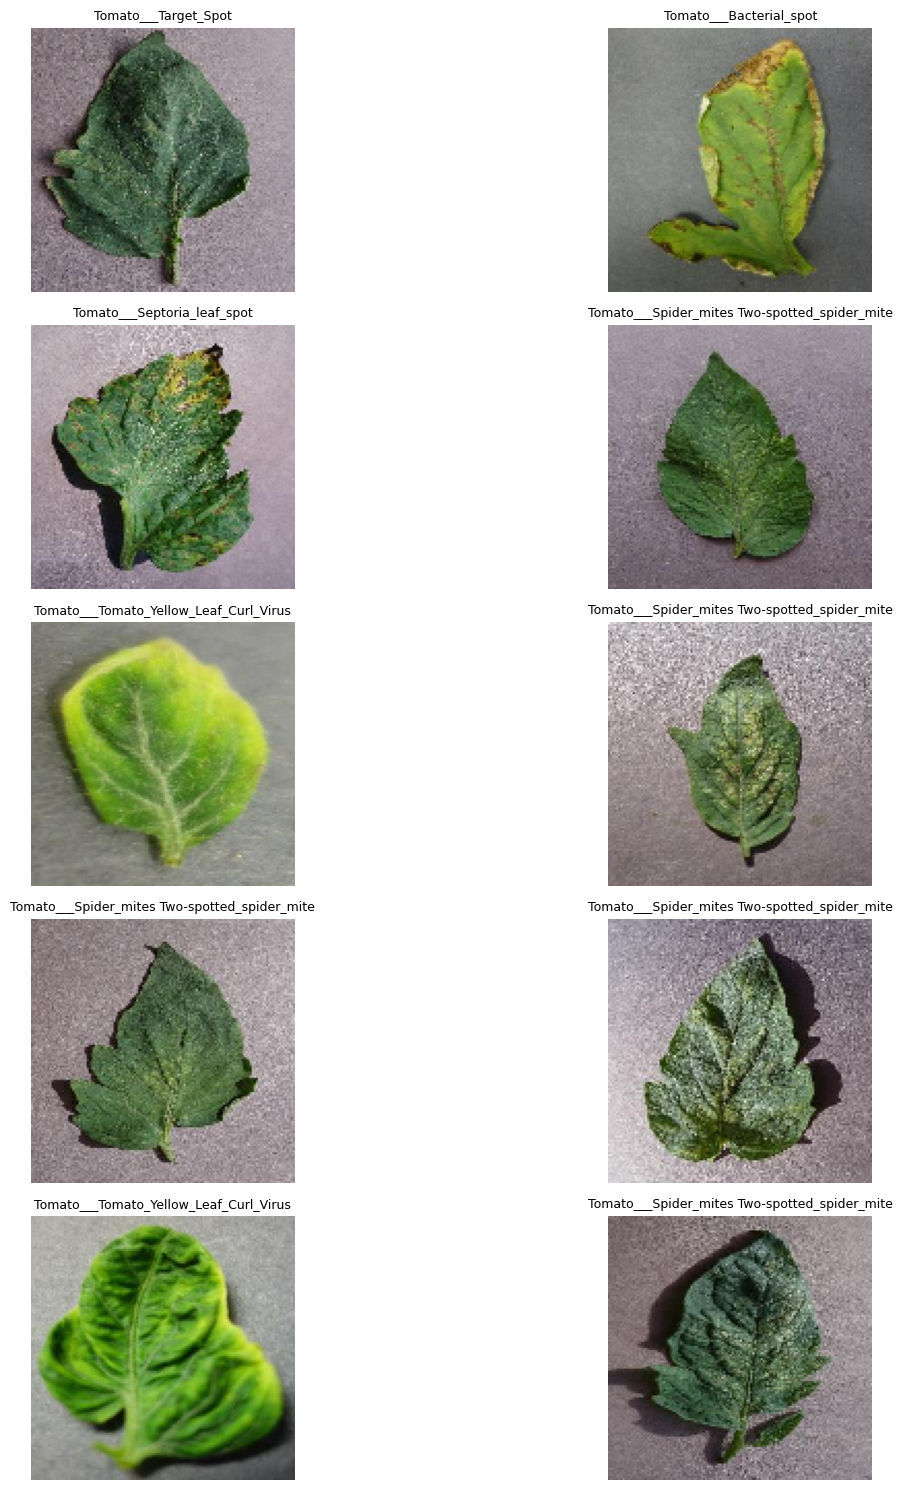

In [37]:
images,labels=next(train_gen)
print(f'Train data shape: {images.shape}')
plt.figure(figsize=(15, 15))
for i in range(10):
    ax = plt.subplot(5, 2, i + 1)
    plt.imshow(images[i])
    plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## Step 7: Build & Train the Convolutional Neural Network (CNN) classifier

In [39]:
inputs2 = Input(shape=(H, W, C))

e = Conv2D(128, (3,3), activation='relu', padding='same')(inputs2)
e = MaxPooling2D((2,2))(e)

e = Conv2D(128,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)
e = Conv2D(64,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)
e = Conv2D(64,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)
e = Conv2D(32,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)
e = Conv2D(32,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)
e = Conv2D(16,  (3,3), activation='relu', padding='same')(e)
e = MaxPooling2D((2,2))(e)

e = Flatten()(e)
e = Dense(10,   activation='relu')(e)
e = Dropout(0.2)(e)
e = Dense(1000, activation='relu')(e)
e = Dropout(0.3)(e)
e = Dense(700,  activation='relu')(e)
e = Dropout(0.5)(e)
e = Dense(350,  activation='relu')(e)
output = Dense(10, activation='softmax')(e)

cnn_model = Model(inputs2, output, name='cnn_classifier')
cnn_model.summary()

Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_58 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_59 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_60 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_61 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_62 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 2, 2, 16)       │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1000)           │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 700)            │       700,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 350)            │       245,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         3,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,254,954 (4.79 MB)

 Trainable params: 1,254,954 (4.79 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    epochs=20,
    validation_data=test_gen,
    validation_steps=len(test_gen)
)

cnn_model.save('/content/drive/MyDrive/TomatoModel/cnn.h5')
print('CNN saved to Google Drive!')

Epoch 1/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 47s 92ms/step - accuracy: 0.3895 - loss: 1.7147 - val_accuracy: 0.4655 - val_loss: 1.5302
Epoch 2/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.5397 - loss: 1.3158 - val_accuracy: 0.6337 - val_loss: 1.0551
Epoch 3/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.6347 - loss: 1.0525 - val_accuracy: 0.6456 - val_loss: 1.0664
Epoch 4/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 30s 69ms/step - accuracy: 0.6999 - loss: 0.8629 - val_accuracy: 0.7386 - val_loss: 0.6911
Epoch 5/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.7407 - loss: 0.7347 - val_accuracy: 0.7754 - val_loss: 0.6247
Epoch 6/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.7683 - loss: 0.6500 - val_accuracy: 0.8188 - val_loss: 0.5078
Epoch 7/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 35s 81ms/step - accuracy: 0.8089 - loss: 0.5552 - val_accuracy: 0.8272 - val_loss: 0.5006
Epoch 8/20
426/426 ━━━━━━━━━━━━━━━━━━━━ 29s 69ms/step - accuracy: 0.8354 - loss: 0.4917 - 

CNN saved to Google Drive!


## Step 8: Evaluate & Plot Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


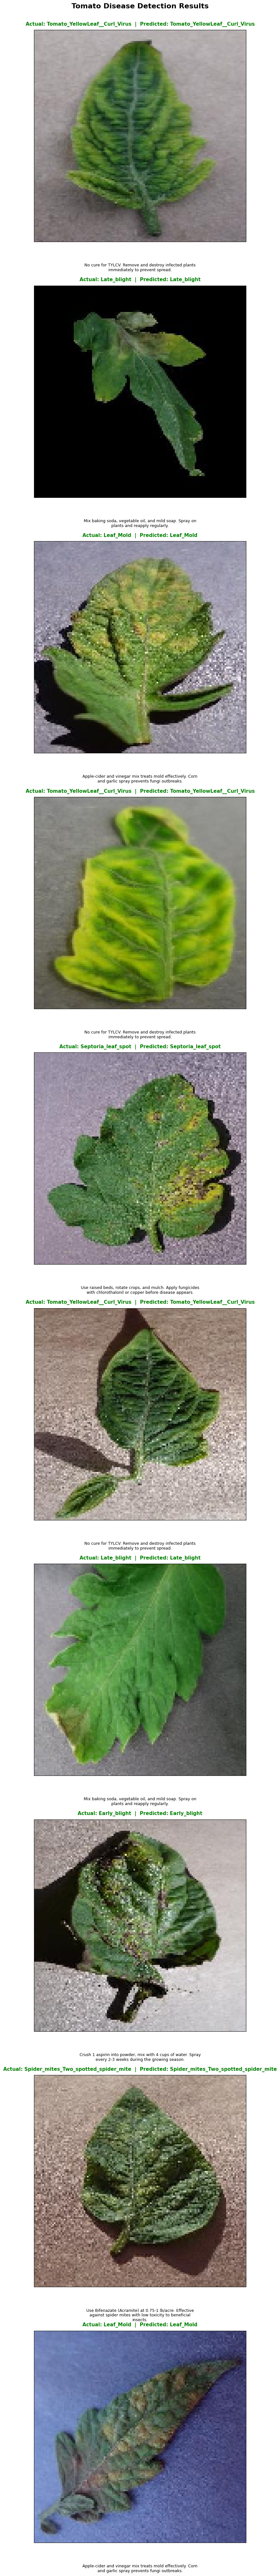

 Plot saved!


In [53]:
import textwrap
test_gen.reset()
images, labels = next(test_gen)

predictions = cnn_model.predict(images[:10])
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(10, 1, figsize=(15, 80))

for i in range(10):
    actual    = CLASS_NAMES[int(labels[i])].replace('Tomato___', '')
    predicted = CLASS_NAMES[predicted_classes[i]].replace('Tomato___', '')
    solution  = SOLUTIONS[predicted_classes[i]]
    correct   = int(labels[i]) == predicted_classes[i]

    axes[i].imshow(images[i])

    axes[i].set_title(
        f'Actual: {actual}  |  Predicted: {predicted}',
        color='green' if correct else 'red',
        fontsize=11,
        fontweight='bold',
        pad=10
    )


    axes[i].text(
        0.5, -0.1,
        textwrap.fill(solution, width=60),
        transform=axes[i].transAxes,
        fontsize=9,
        ha='center',
        va='top',
        wrap=True
    )

    axes[i].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

plt.suptitle('Tomato Disease Detection Results', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.savefig('results.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Plot saved!')